# Security Threat Detection — Bayes' Rule

Scenario:

Only **1 in 100,000** login attempts is malicious.

Your detector:

- Detects **99%** of attacks
- Has a false-alarm rate of **0.1%**

An alert is triggered.

Question:

> What is the probability that the alert is a real attack?

This is a Bayes' Rule problem because we are given:

$$P(\text{Alert} \mid \text{Attack})$$

but we want:

$$P(\text{Attack} \mid \text{Alert})$$


## Step 1: Define the Hypotheses

Let:

- `Attack` = login attempt is malicious
- `Normal` = login attempt is not malicious

Evidence:

- `Alert` = detector triggers an alert


In [1]:
priors = {
    "Attack": 1 / 100_000,
    "Normal": 1 - (1 / 100_000),
}

likelihoods = {
    "Attack": 0.99,     # P(Alert | Attack)
    "Normal": 0.001,    # P(Alert | Normal), false-alarm rate
}

priors, likelihoods

({'Attack': 1e-05, 'Normal': 0.99999}, {'Attack': 0.99, 'Normal': 0.001})

## Step 2: Solve Analytically Using `explain_update()`

The evidence is:

```text
Alert triggered
```

So we update the prior probabilities using the likelihood of seeing an alert under each hypothesis.


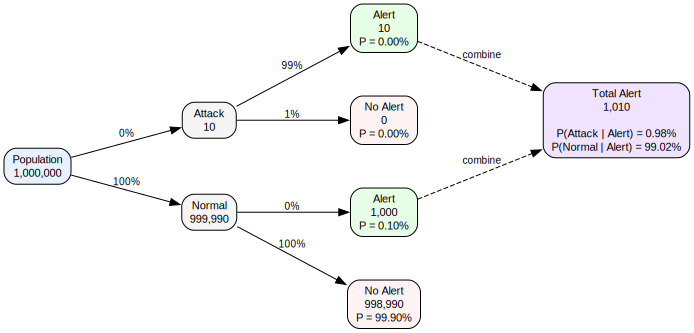

In [2]:
from probmodels import explain_update

result = explain_update(
    priors=priors,
    likelihoods=likelihoods,
    population_size=1_000_000,
    evidence_name="Alert",
    no_evidence_name="No Alert",
    draw_tree=True,
    edge_label_style="short",
    show_joint_probabilities=True,
    show_posterior_node=True,
)

result["tree"]

In [3]:
result["posteriors"]

{'Attack': 0.009803047856697264, 'Normal': 0.9901969521433027}

## Step 3: Interpret with Counts

Using 1,000,000 login attempts:

- Expected attacks: about 10
- Alerts from attacks: about 9.9
- Normal attempts: about 999,990
- False alerts from normal attempts: about 999.99

So most alerts are actually false alarms, even though the detector is very sensitive.


In [4]:
result["counts"]

{'Attack': {'hypothesis_count': 10,
  'evidence_count': 10,
  'no_evidence_count': 0},
 'Normal': {'hypothesis_count': 999990,
  'evidence_count': 1000,
  'no_evidence_count': 998990}}

In [5]:
p_attack_given_alert = result["posteriors"]["Attack"]

print(f"P(Attack | Alert) = {p_attack_given_alert:.4f}")
print(f"P(Attack | Alert) = {p_attack_given_alert:.2%}")

P(Attack | Alert) = 0.0098
P(Attack | Alert) = 0.98%


## Step 4: Verify Using `simulate_bayes()`

Now simulate many login attempts and estimate the same posterior probability.


In [6]:
from probmodels import simulate_bayes

sim_result = simulate_bayes(
    priors=priors,
    likelihoods=likelihoods,
    n=5_000_000,
    hypothesis_name="Login Type",
    evidence_name="Alert",
    seed=42,
)

sim_result["table"]

Login Type,Attack,Normal,All
Alert,,,
False,1,4995083,4995084
True,41,4875,4916
All,42,4999958,5000000


In [7]:
sim_result["posterior_exact"]

{'Attack': 0.009803047856697264, 'Normal': 0.9901969521433027}

In [8]:
sim_result["posterior_simulated"]

Login Type
Attack    0.00834
Normal    0.99166
Name: proportion, dtype: float64

In [9]:
print(sim_result["posterior_formulas"]["Attack"])

KeyError: 'posterior_formulas'

## Step 5: Compare Exact vs Simulated Results

In [ ]:
import pandas as pd

comparison = pd.DataFrame(
    {
        "Exact": sim_result["posterior_exact"],
        "Simulated": sim_result["posterior_simulated"],
    }
)

comparison

## Final Answer

Even though the detector catches **99% of attacks**, attacks are extremely rare.

The posterior probability is only about:

$$P(\text{Attack} \mid \text{Alert}) \approx 0.0098$$

or about:

$$0.98\%$$

So, if an alert is triggered, the chance that it is a real attack is **less than 1%**.

This is a classic **base-rate fallacy** example.


## Key Takeaways

1. Rare events have very small priors.
2. Even a low false-alarm rate can create many false positives when normal cases are extremely common.
3. Bayes' Rule helps convert:

$$P(\text{Alert} \mid \text{Attack})$$

into:

$$P(\text{Attack} \mid \text{Alert})$$

4. In security systems, alert volume can be dominated by false positives.
